## Exploratory EOF analysis

In [7]:
# Setup: config + imports
import glob
import os
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import AutoMinorLocator
import cartopy.crs as ccrs
import cartopy.feature as cfeature

OUT_DIR      = "../Figures"

In [1]:
import xarray as xr

detr_field = xr.open_dataarray("detr_field.nc")
detr_field

<xarray.DataArray (time: 276, lat: 36, lon: 61)> Size: 5MB
[606096 values with dtype=float64]
Coordinates:
  * time     (time) datetime64[ns] 2kB 2003-01-01 2003-02-01 ... 2025-12-01
  * lat      (lat) float32 144B 14.5 15.5 16.5 17.5 18.5 ... 46.5 47.5 48.5 49.5
  * lon      (lon) float32 244B -126.5 -125.5 -124.5 ... -68.5 -67.5 -66.5

Mode 1: 82.3% of variance
Mode 2: 7.1% of variance
Mode 3: 3.7% of variance
Mode 4: 1.2% of variance
Mode 5: 0.9% of variance
Mode 6: 0.6% of variance
Mode 7: 0.5% of variance
Mode 8: 0.4% of variance
Mode 9: 0.3% of variance
Mode 10: 0.3% of variance
Mode 11: 0.2% of variance
Mode 12: 0.2% of variance
Mode 13: 0.1% of variance
Mode 14: 0.1% of variance
Mode 15: 0.1% of variance
Mode 16: 0.1% of variance
Mode 17: 0.1% of variance
Mode 18: 0.1% of variance
Mode 19: 0.1% of variance
Mode 20: 0.1% of variance
Mode 21: 0.1% of variance
Mode 22: 0.1% of variance
Mode 23: 0.1% of variance
Mode 24: 0.0% of variance
Mode 25: 0.0% of variance
Mode 26: 0.0% of variance
Mode 27: 0.0% of variance
Mode 28: 0.0% of variance
Mode 29: 0.0% of variance
Mode 30: 0.0% of variance
Mode 31: 0.0% of variance
Mode 32: 0.0% of variance
Mode 33: 0.0% of variance
Mode 34: 0.0% of variance
Mode 35: 0.0% of variance
Mode 36: 0.0% of variance
Mode 37: 0.0% of variance
Mode 38: 0.0% of variance
Mode 39: 0.0% of var

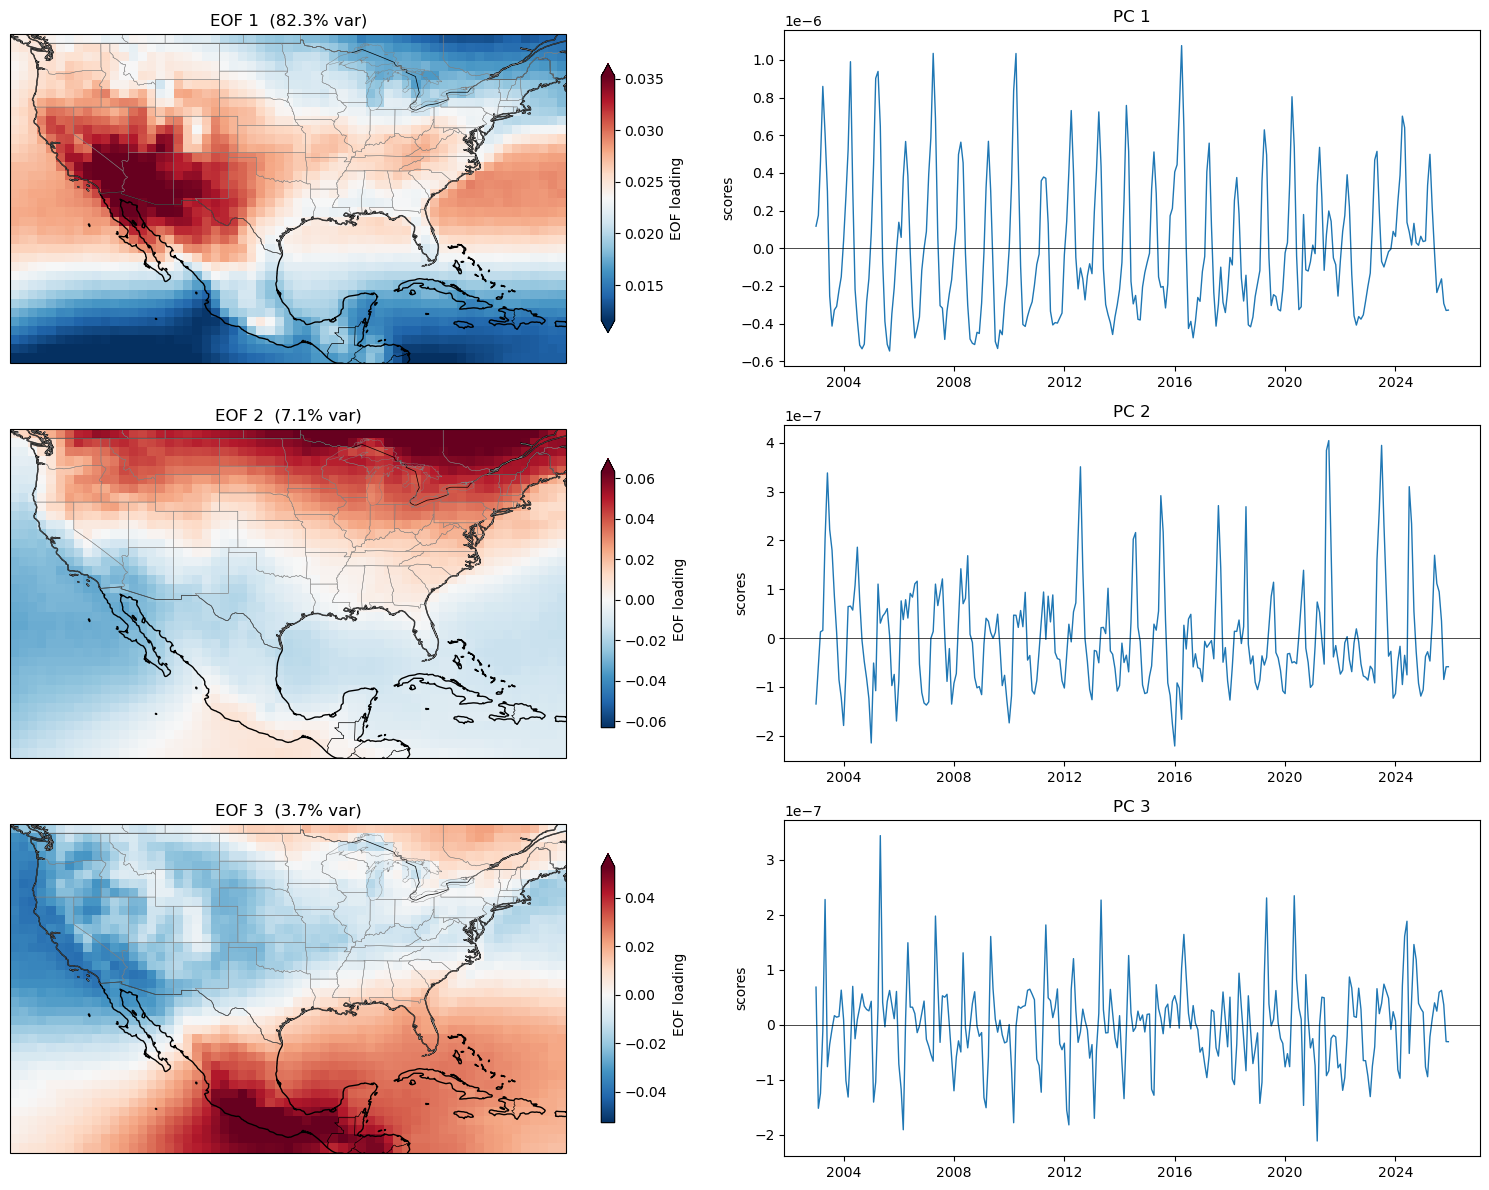

Saved -> ../Figures\eof_detrended_2003_2025.png


In [10]:
# EOF on the per-pixel detrended field 
from xeofs.single import EOF


model = EOF(n_modes=276, use_coslat=True)
model.fit(detr_field, dim="time")
eofs   = model.components()                       # (mode, lat, lon)
pcs    = model.scores()                           # (mode, time)
expvar = model.explained_variance_ratio().values * 100
coslat_w = np.sqrt(np.cos(np.deg2rad(eofs.lat)))
eofs = eofs / coslat_w  # broadcasts over lat
for i, v in enumerate(expvar, start=1):
    print(f"Mode {i}: {v:.1f}% of variance")

# Plot first 3 modes: spatial pattern + PC.
n_show = 3
fig_eof = plt.figure(figsize=(15, 4 * n_show))
for i in range(n_show):
    ax_map = fig_eof.add_subplot(n_show, 2, 2*i + 1, projection=ccrs.PlateCarree())
    eofs.sel(mode=i+1).plot(
        ax=ax_map, transform=ccrs.PlateCarree(), cmap="RdBu_r", robust=True,
        cbar_kwargs={"label": "EOF loading", "shrink": 0.8},
    )
    ax_map.coastlines()
    ax_map.add_feature(cfeature.BORDERS, lw=0.5)
    ax_map.add_feature(cfeature.STATES, lw=0.3, edgecolor="gray")
    ax_map.set_title(f"EOF {i+1}  ({expvar[i]:.1f}% var)")

    ax_pc = fig_eof.add_subplot(n_show, 2, 2*i + 2)
    pcs.sel(mode=i+1).plot(ax=ax_pc, lw=1)
    ax_pc.axhline(0, color="k", lw=0.5)
    ax_pc.set_title(f"PC {i+1}")
    ax_pc.set_xlabel("")

plt.tight_layout()
out_eof = os.path.join(OUT_DIR, "eof_detrended_2003_2025.png")
fig_eof.savefig(out_eof, dpi=150, bbox_inches="tight")
plt.show()
print("Saved ->", out_eof)

Mode 1: 82.3% of variance
Mode 2: 7.1% of variance
Mode 3: 3.7% of variance
Mode 4: 1.2% of variance
Mode 5: 0.9% of variance
Mode 6: 0.6% of variance
Mode 7: 0.5% of variance
Mode 8: 0.4% of variance
Mode 9: 0.3% of variance
Mode 10: 0.3% of variance
Mode 11: 0.2% of variance
Mode 12: 0.2% of variance
Mode 13: 0.1% of variance
Mode 14: 0.1% of variance
Mode 15: 0.1% of variance
Mode 16: 0.1% of variance
Mode 17: 0.1% of variance
Mode 18: 0.1% of variance
Mode 19: 0.1% of variance
Mode 20: 0.1% of variance
Mode 21: 0.1% of variance
Mode 22: 0.1% of variance
Mode 23: 0.1% of variance
Mode 24: 0.0% of variance
Mode 25: 0.0% of variance
Mode 26: 0.0% of variance
Mode 27: 0.0% of variance
Mode 28: 0.0% of variance
Mode 29: 0.0% of variance
Mode 30: 0.0% of variance
Mode 31: 0.0% of variance
Mode 32: 0.0% of variance
Mode 33: 0.0% of variance
Mode 34: 0.0% of variance
Mode 35: 0.0% of variance
Mode 36: 0.0% of variance
Mode 37: 0.0% of variance
Mode 38: 0.0% of variance
Mode 39: 0.0% of var

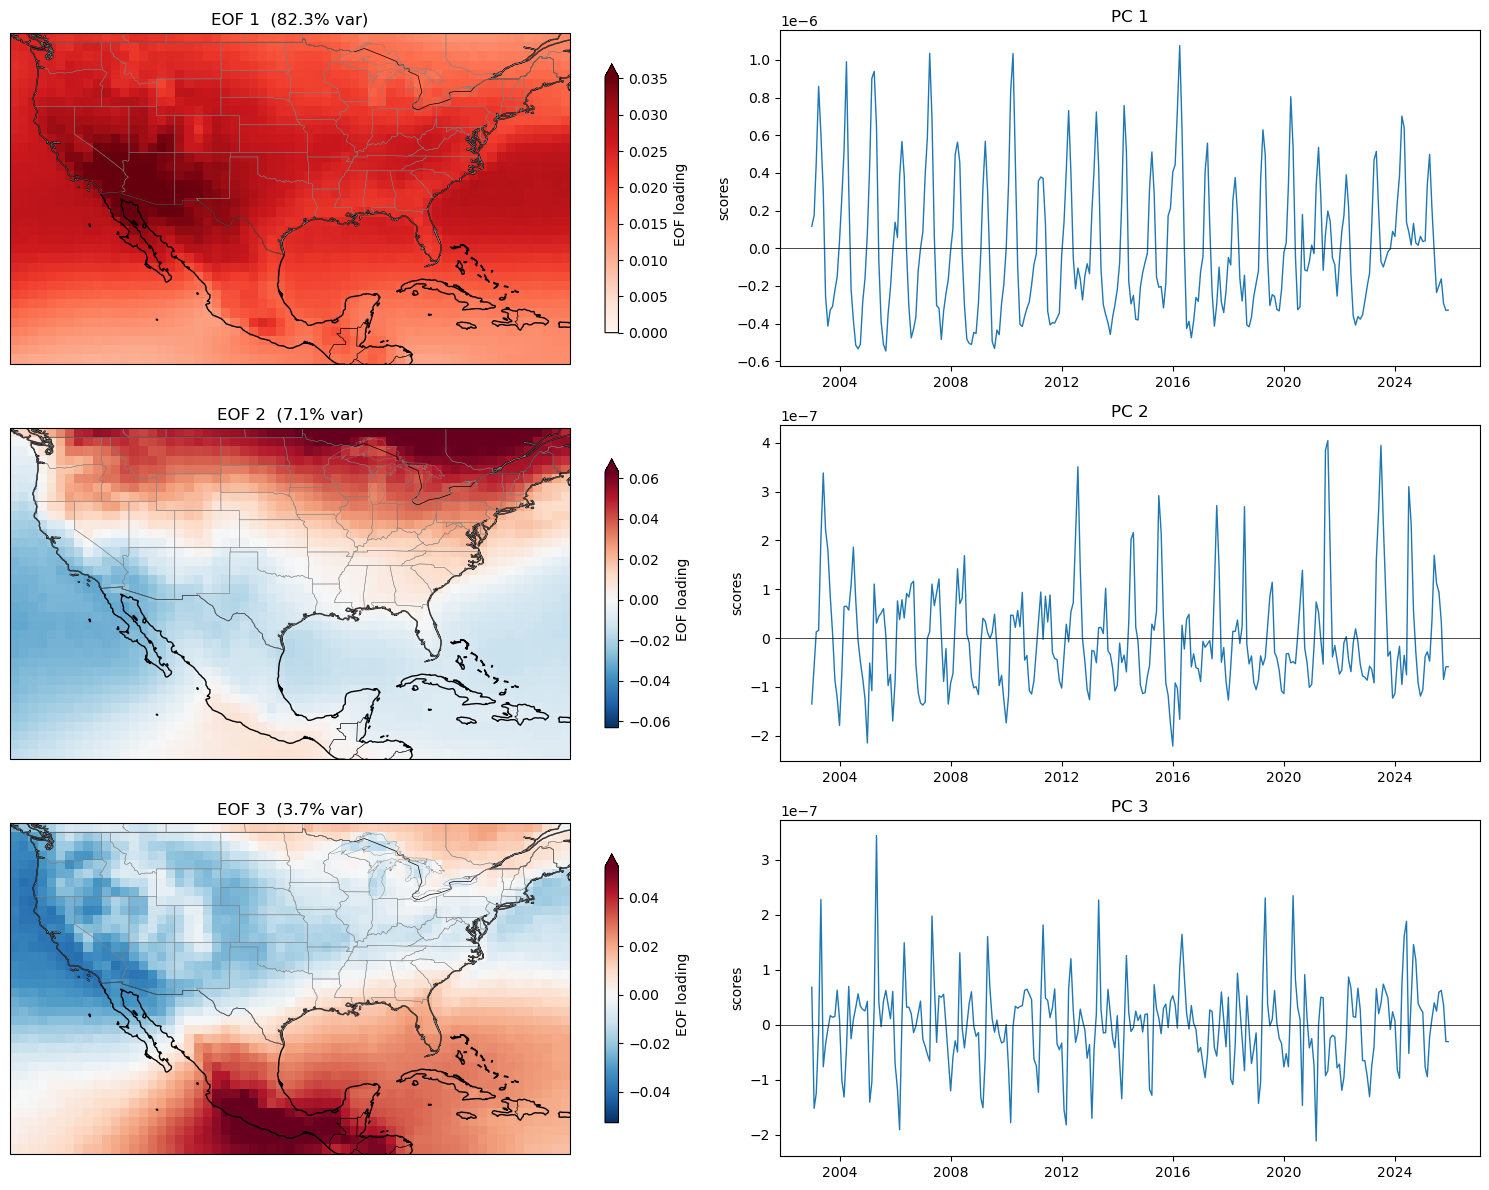

Saved -> ../Figures\eof_detrended_2003_2025.png


In [43]:
# EOF on the per-pixel detrended field 
from xeofs.single import EOF

model = EOF(n_modes=276, use_coslat=True)
model.fit(detr_field, dim="time")
eofs   = model.components()                       # (mode, lat, lon)
pcs    = model.scores()                           # (mode, time)
expvar = model.explained_variance_ratio().values * 100
coslat_w = np.sqrt(np.cos(np.deg2rad(eofs.lat)))
eofs = eofs / coslat_w  # broadcasts over lat
for i, v in enumerate(expvar, start=1):
    print(f"Mode {i}: {v:.1f}% of variance")

# --- pick a diverging (RdBu_r) or sequential colormap per mode, based on
#     whether the loading actually contains both signs ------------------------
def choose_cmap_and_range(data, robust=True, plow=2, phigh=98):
    """robust=True clips to the [plow, phigh] percentile range before deciding
    sign/extent, same spirit as xarray's robust=True, so a single wild outlier
    pixel can't blow out the whole color scale."""
    vals = np.asarray(data)
    vals = vals[np.isfinite(vals)]
    if robust:
        lo, hi = np.nanpercentile(vals, [plow, phigh])
    else:
        lo, hi = np.nanmin(vals), np.nanmax(vals)

    has_pos, has_neg = hi > 0, lo < 0

    if has_pos and has_neg:
        vext = max(abs(lo), abs(hi))          # symmetric range -> 0 sits at the colormap center
        return "RdBu_r", -vext, vext
    elif has_pos:                              # all positive: no reason to reserve half the
        return "Reds", 0.0, hi                 # colormap for a blue that will never appear
    else:                                       # all negative
        return "Blues_r", lo, 0.0

# Plot first 3 modes: spatial pattern + PC.
n_show = 3
fig_eof = plt.figure(figsize=(15, 4 * n_show))
for i in range(n_show):
    eof_i = eofs.sel(mode=i+1)
    cmap_i, vmin_i, vmax_i = choose_cmap_and_range(eof_i.values)

    ax_map = fig_eof.add_subplot(n_show, 2, 2*i + 1, projection=ccrs.PlateCarree())
    eof_i.plot(
        ax=ax_map, transform=ccrs.PlateCarree(), cmap=cmap_i,
        vmin=vmin_i, vmax=vmax_i,
        cbar_kwargs={"label": "EOF loading", "shrink": 0.8},
    )
    ax_map.coastlines()
    ax_map.add_feature(cfeature.BORDERS, lw=0.5)
    ax_map.add_feature(cfeature.STATES, lw=0.3, edgecolor="gray")
    ax_map.set_title(f"EOF {i+1}  ({expvar[i]:.1f}% var)")

    ax_pc = fig_eof.add_subplot(n_show, 2, 2*i + 2)
    pcs.sel(mode=i+1).plot(ax=ax_pc, lw=1)
    ax_pc.axhline(0, color="k", lw=0.5)
    ax_pc.set_title(f"PC {i+1}")
    ax_pc.set_xlabel("")

plt.tight_layout()
out_eof = os.path.join(OUT_DIR, "eof_detrended_2003_2025.png")
fig_eof.savefig(out_eof, dpi=150, bbox_inches="tight")
plt.show()
print("Saved ->", out_eof)

## Complex (Hilbert) EOF with xeofs

Ordinary EOF gives *standing* patterns: a mode can only grow and shrink in place.
Complex EOF first applies a Hilbert transform to each pixel's time series, which adds an
imaginary part carrying the same signal shifted by a quarter cycle. The modes then come
out complex, so each one has an **amplitude** (how strong the pattern is) and a **phase**
(*when* it peaks). That lets a single mode describe a feature that *travels* across the
map, instead of only pulsing in place.


**Fit the complex EOF.** `padding="exp"` tapers the ends of the record before the
Hilbert transform, which reduces edge artefacts (spectral leakage).



In [33]:
# Complex (Hilbert) EOF on the detrended field.
from xeofs.single import HilbertEOF

cmodel = HilbertEOF(n_modes=276, use_coslat=True, padding="exp", decay_factor=0.2,
                    solver="full")
cmodel.fit(detr_field, dim="time")

cexpvar = cmodel.explained_variance_ratio().values * 100

print("Complex (Hilbert) EOF — variance explained")
for i, v in enumerate(cexpvar, start=1):
    print(f"  Mode {i:2d}: {v:.1f}%")
print(f"\n  First 3 modes together: {cexpvar[:3].sum():.1f}%")

Complex (Hilbert) EOF — variance explained
  Mode  1: 85.0%
  Mode  2: 6.5%
  Mode  3: 2.2%
  Mode  4: 1.2%
  Mode  5: 0.8%
  Mode  6: 0.6%
  Mode  7: 0.5%
  Mode  8: 0.4%
  Mode  9: 0.3%
  Mode 10: 0.2%
  Mode 11: 0.2%
  Mode 12: 0.2%
  Mode 13: 0.1%
  Mode 14: 0.1%
  Mode 15: 0.1%
  Mode 16: 0.1%
  Mode 17: 0.1%
  Mode 18: 0.1%
  Mode 19: 0.1%
  Mode 20: 0.1%
  Mode 21: 0.1%
  Mode 22: 0.1%
  Mode 23: 0.1%
  Mode 24: 0.0%
  Mode 25: 0.0%
  Mode 26: 0.0%
  Mode 27: 0.0%
  Mode 28: 0.0%
  Mode 29: 0.0%
  Mode 30: 0.0%
  Mode 31: 0.0%
  Mode 32: 0.0%
  Mode 33: 0.0%
  Mode 34: 0.0%
  Mode 35: 0.0%
  Mode 36: 0.0%
  Mode 37: 0.0%
  Mode 38: 0.0%
  Mode 39: 0.0%
  Mode 40: 0.0%
  Mode 41: 0.0%
  Mode 42: 0.0%
  Mode 43: 0.0%
  Mode 44: 0.0%
  Mode 45: 0.0%
  Mode 46: 0.0%
  Mode 47: 0.0%
  Mode 48: 0.0%
  Mode 49: 0.0%
  Mode 50: 0.0%
  Mode 51: 0.0%
  Mode 52: 0.0%
  Mode 53: 0.0%
  Mode 54: 0.0%
  Mode 55: 0.0%
  Mode 56: 0.0%
  Mode 57: 0.0%
  Mode 58: 0.0%
  Mode 59: 0.0%
  Mode 60: 0

**The outputs are complex.** Each mode splits into an amplitude and a phase, for both the spatial pattern and the time series.

In [34]:
# Complex components and scores, and their amplitude / phase parts.
ceofs = cmodel.components()              # (mode, lat, lon)  complex
cpcs  = cmodel.scores()                  # (mode, time)      complex

ceof_amp = cmodel.components_amplitude()     # spatial amplitude (still coslat-weighted)
ceof_pha = cmodel.components_phase()         # spatial phase (radians, -pi..pi)
cpc_amp  = cmodel.scores_amplitude()         # temporal amplitude
cpc_pha  = cmodel.scores_phase()             # temporal phase (radians)

print("components :", ceofs.dims, ceofs.dtype)
print("scores     :", cpcs.dims, cpcs.dtype)
print("phase range: {:.2f} to {:.2f} rad".format(float(ceof_pha.min()), float(ceof_pha.max())))

# --- coslat correction for amplitude 
coslat_w = np.sqrt(np.cos(np.deg2rad(ceof_amp.lat)))   # DataArray with 'lat' coord -> broadcasts 
ceof_amp_corr = ceof_amp / coslat_w

# --- per-mode diagnostics: period, coherence proxy, variance table ---
n_diag = min(10, cmodel.n_modes) if hasattr(cmodel, "n_modes") else 10
time_axis = np.arange(cpcs.sizes["time"])   # step index; each step = 1 month in this dataset

print(f"\n{'Mode':>4} {'Var%':>7} {'CumVar%':>8} {'Period(mo)':>11} {'Period(yr)':>11}")
mode_periods = {}
cum = 0.0
for k in range(1, n_diag + 1):
    cum += cexpvar[k-1]
    ph_t = cpc_pha.sel(mode=k).values                     # radians, PC phase over time
    ph_unwrap = np.unwrap(ph_t)
    slope = np.polyfit(time_axis, ph_unwrap, 1)[0]         # rad / month
    period_months = np.nan if slope == 0 else 2*np.pi / slope
    mode_periods[k] = period_months
    print(f"{k:>4} {cexpvar[k-1]:>7.2f} {cum:>8.2f} {period_months:>11.2f} {period_months/12:>11.2f}")

print(f"\nFirst 3 modes together: {cexpvar[:3].sum():.1f}% of variance")

components : ('mode', 'lat', 'lon') complex128
scores     : ('mode', 'time') complex128
phase range: -3.14 to 3.14 rad

Mode    Var%  CumVar%  Period(mo)  Period(yr)
   1   84.97    84.97       12.17        1.01
   2    6.45    91.42        6.87        0.57
   3    2.19    93.60        8.38        0.70
   4    1.17    94.77        7.40        0.62
   5    0.82    95.59        9.93        0.83
   6    0.60    96.19        6.70        0.56
   7    0.50    96.69        6.35        0.53
   8    0.36    97.05        7.36        0.61
   9    0.28    97.33        7.05        0.59
  10    0.23    97.56        8.36        0.70

First 3 modes together: 93.6% of variance


**Plot: spatial amplitude and phase of the first three modes.** Amplitude shows *where* the mode acts; phase shows *when* each place peaks, so a smooth phase gradient means the signal is propagating in that direction.

Mode 3: phase wraps the 0/360 seam -> showing full colorbar


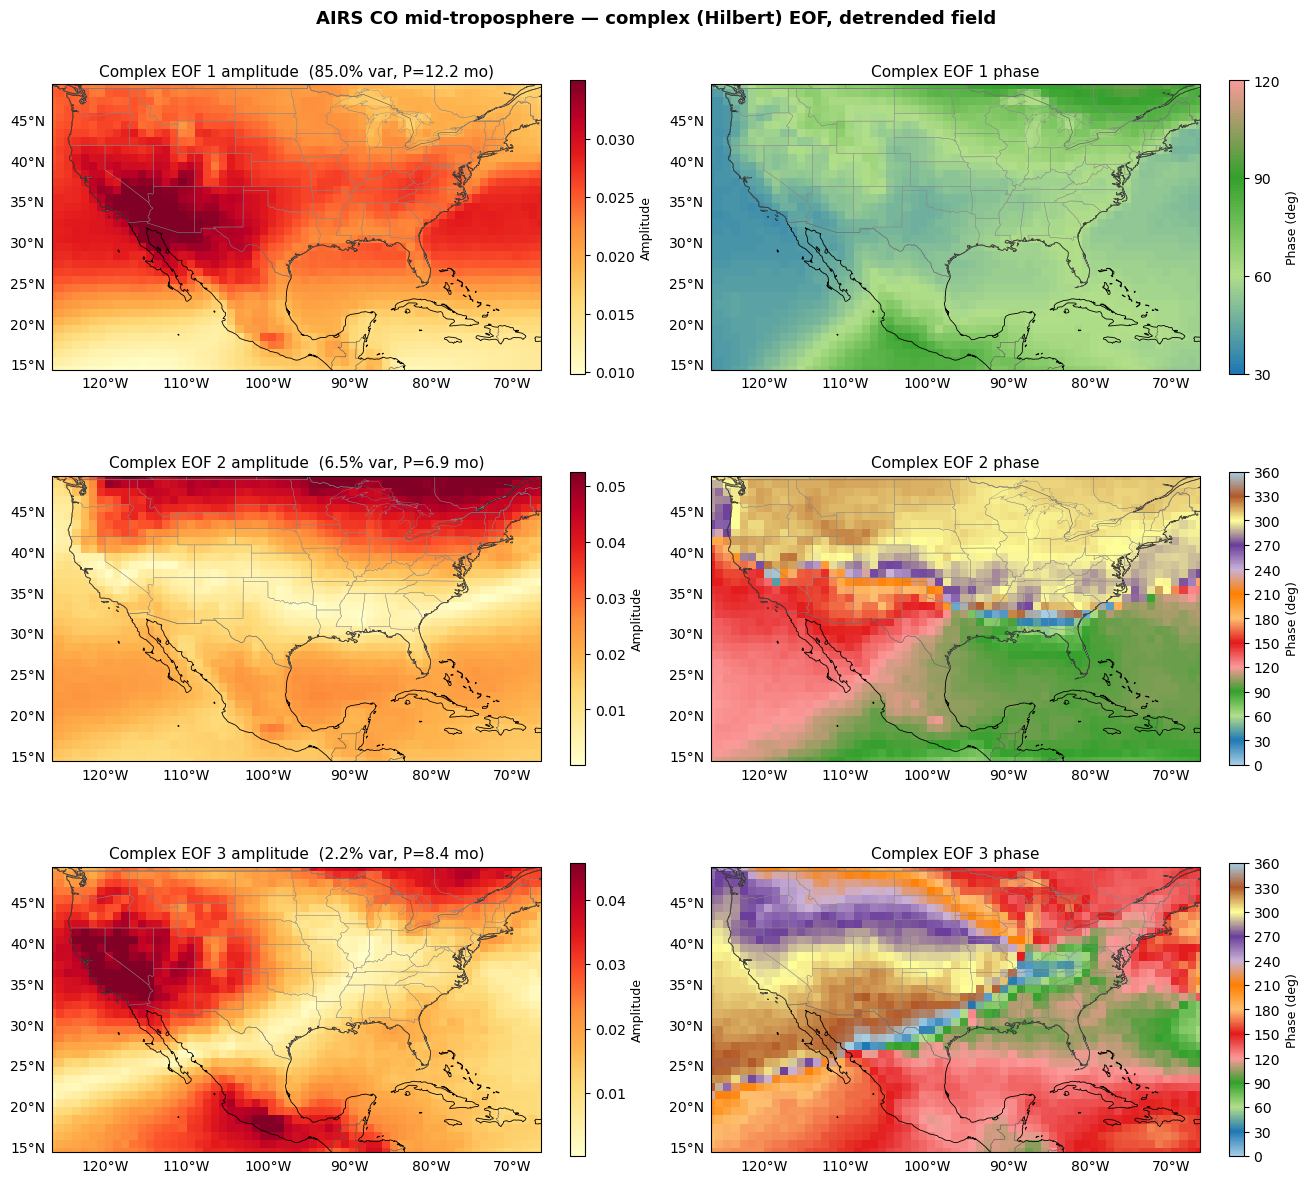

Saved -> ../Figures\ceof_amp_phase_2003_2025.png


In [35]:
import matplotlib.colors as mcolors
import itertools

lons = detr_field["lon"].values
lats = detr_field["lat"].values

ext = [float(lons.min()), float(lons.max()),
       float(lats.min()), float(lats.max())]


distinct_colors = plt.get_cmap("Paired").colors   # exactly 12 distinct colors, one per 30-deg bin

def build_fixed_phase_cmap():
    bin_starts = np.arange(0, 360, 30)                      # 0,30,...,330 (12 anchors)
    n_bins = len(bin_starts)                                 # = 12, matches len(distinct_colors) exactly
    bin_colors = list(itertools.islice(itertools.cycle(distinct_colors), n_bins))
    anchor_colors = bin_colors + [bin_colors[0]]             # force color(360) == color(0)
    cmap = mcolors.LinearSegmentedColormap.from_list("phase_fixed", anchor_colors, N=360)
    norm = mcolors.Normalize(vmin=0, vmax=360)
    return cmap, norm

phase_cmap, phase_norm = build_fixed_phase_cmap()

def circular_range(deg_vals):
    """Smallest contiguous window (mod 360) containing all finite values, found
    by locating the single largest empty gap on the circle."""
    v = np.sort(np.mod(deg_vals[np.isfinite(deg_vals)], 360))
    if v.size == 0:
        return 0.0, 360.0, False
    gaps = np.diff(np.concatenate([v, [v[0] + 360]]))
    k = np.argmax(gaps)
    start = v[(k + 1) % v.size]
    end = start + (360 - gaps[k])
    return float(start), float(end), end > 360

def crop_to_30deg(lo, hi):
    """Round the display window out to the nearest enclosing multiples of 30,
    so the colorbar never starts or ends mid-bin."""
    return float(np.floor(lo / 30) * 30), float(np.ceil(hi / 30) * 30)

def ceof_map(ax, data, cmap, label, title, vmin=None, vmax=None, norm=None):
    ax.set_extent(ext, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor="k")
    ax.add_feature(cfeature.BORDERS,   linewidth=0.4, edgecolor="#555")
    ax.add_feature(cfeature.STATES,    linewidth=0.25, edgecolor="#888")
    pcm = ax.pcolormesh(lons, lats, data, transform=ccrs.PlateCarree(),
                        cmap=cmap, vmin=vmin, vmax=vmax, norm=norm, shading="nearest")
    gl = ax.gridlines(draw_labels=True, linewidth=0, color="none")
    gl.top_labels = gl.right_labels = False
    cb = fig_ca.colorbar(pcm, ax=ax, orientation="vertical", fraction=0.03, pad=0.06)
    cb.set_label(label, fontsize=9)
    ax.set_title(title, fontsize=11, pad=6)
    return cb

n_show = 3
fig_ca, axes_ca = plt.subplots(
    n_show, 2, figsize=(13, 4 * n_show),
    subplot_kw={"projection": ccrs.PlateCarree()}, constrained_layout=True,
)

for i in range(n_show):
    mode_k = i + 1
    amp_i = ceof_amp_corr.sel(mode=mode_k).values               # coslat-corrected amplitude
    pha_i = np.rad2deg(ceof_pha.sel(mode=mode_k).values) % 360  # -> 0..360

    ceof_map(axes_ca[i, 0], amp_i, "YlOrRd", "Amplitude",
             f"Complex EOF {mode_k} amplitude  ({cexpvar[i]:.1f}% var, "
             f"P={mode_periods[mode_k]:.1f} mo)",
             vmax=np.nanpercentile(amp_i, 98))

    # phase: fixed global colormap/norm (same color = same angle everywhere),
    # colorbar cropped to the actual data range, rounded out to multiples of 30
    start, end, wraps = circular_range(pha_i)
    cb = ceof_map(axes_ca[i, 1], pha_i, phase_cmap, "Phase (deg)",
                  f"Complex EOF {mode_k} phase", norm=phase_norm)

    if not wraps:
        lo30, hi30 = crop_to_30deg(start, end)
        cb.ax.set_ylim(lo30, hi30)
        ticks = np.arange(lo30, hi30 + 1e-6, 30)
    else:
        # data straddle the 0/360 seam -- a single linear crop can't represent
        # that on one colorbar axis, so show the full cyclic bar for this mode
        ticks = np.arange(0, 361, 30)
        print(f"Mode {mode_k}: phase wraps the 0/360 seam -> showing full colorbar")
    cb.set_ticks(ticks)

fig_ca.suptitle("AIRS CO mid-troposphere — complex (Hilbert) EOF, detrended field",
                fontsize=13, fontweight="bold")
out_ca = os.path.join(OUT_DIR, "ceof_amp_phase_2003_2025.png")
fig_ca.savefig(out_ca, dpi=150, bbox_inches="tight")
plt.show()
print("Saved ->", out_ca)

Mode 1: box coherence = 0.994
Mode 1: relative phase wraps the 0/360 seam -> showing full colorbar


C:\Users\ACER\AppData\Local\Temp\ipykernel_4216\3907922913.py:50: UserWarning: Adding colorbar to a different Figure <Figure size 1300x450 with 3 Axes> than <Figure size 1300x1200 with 12 Axes> which fig.colorbar is called on.
  cb = fig_ca.colorbar(pcm, ax=ax, orientation="vertical", fraction=0.03, pad=0.06)
C:\Users\ACER\AppData\Local\Temp\ipykernel_4216\3907922913.py:50: UserWarning: Adding colorbar to a different Figure <Figure size 1300x450 with 4 Axes> than <Figure size 1300x1200 with 12 Axes> which fig.colorbar is called on.
  cb = fig_ca.colorbar(pcm, ax=ax, orientation="vertical", fraction=0.03, pad=0.06)


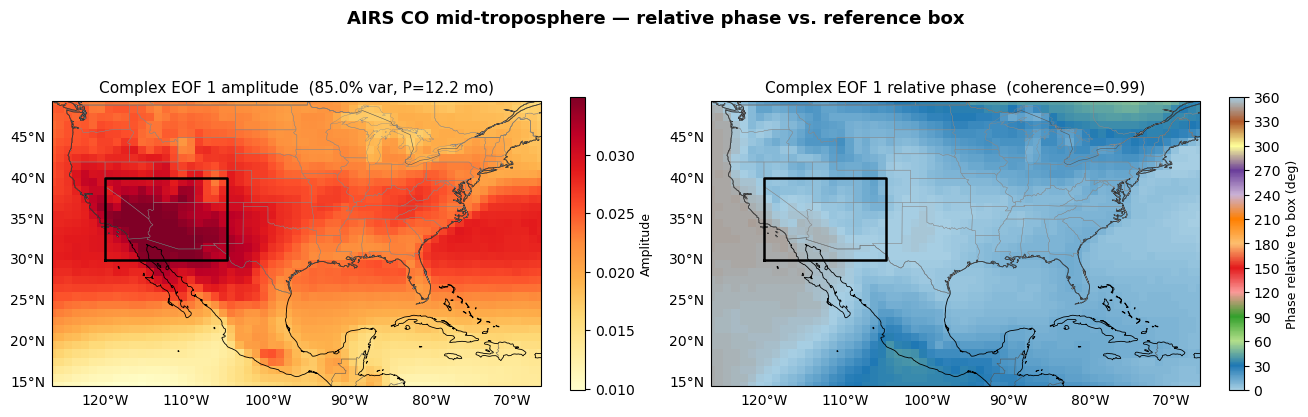

Saved -> ../Figures\ceof_relphase_mode1_2003_2025.png


In [ ]:
# ============================================================
# Relative phase for a single mode, referenced to a lat/lon box
# ============================================================

MODE_K = 1          # which complex EOF mode to plot

LAT0, LAT1 = 30, 40    
LON0, LON1 = -120, -105    

comp_k = ceofs.sel(mode=MODE_K)                       # complex, (lat, lon)
amp_k  = ceof_amp_corr.sel(mode=MODE_K).values         # coslat-corrected amplitude

# --- complex mean over the box 
box  = comp_k.sel(lat=slice(LAT0, LAT1), lon=slice(LON0, LON1))
wbox = np.cos(np.deg2rad(box.lat))
ref  = (box * wbox).sum(("lat", "lon")) / (wbox * xr.ones_like(box.real)).sum(("lat", "lon"))

# coherence: how in-phase the box's grid points are with each other (1.0 = perfectly coherent)
coherence = float(np.abs(ref) / ((np.abs(box) * wbox).sum() / (wbox * xr.ones_like(box.real)).sum()))
print(f"Mode {MODE_K}: box coherence = {coherence:.3f}"
      + ("  (low -- consider a smaller/more uniform box)" if coherence < 0.8 else ""))

# --- relative phase: multiply by conjugate of the (unit-modulus) reference ---
rel_phase = np.rad2deg(np.angle(comp_k * np.conj(ref) / np.abs(ref))) % 360   # -> 0..360

# ============================================================
# Plot: amplitude (left) + relative phase (right), single mode
# ============================================================
fig_rp, axes_rp = plt.subplots(
    1, 2, figsize=(13, 4.5),
    subplot_kw={"projection": ccrs.PlateCarree()}, constrained_layout=True,
)


ceof_map(axes_rp[0], amp_k, "YlOrRd", "Amplitude",
         f"Complex EOF {MODE_K} amplitude  ({cexpvar[MODE_K-1]:.1f}% var, "
         f"P={mode_periods[MODE_K]:.1f} mo)",
         vmax=np.nanpercentile(amp_k, 98))

start, end, wraps = circular_range(rel_phase)
cb = ceof_map(axes_rp[1], rel_phase, phase_cmap, "Phase relative to box (deg)",
              f"Complex EOF {MODE_K} relative phase  (coherence={coherence:.2f})",
              norm=phase_norm)

if not wraps:
    lo30, hi30 = crop_to_30deg(start, end)
    cb.ax.set_ylim(lo30, hi30)
    ticks = np.arange(lo30, hi30 + 1e-6, 30)
else:
    ticks = np.arange(0, 361, 30)
    print(f"Mode {MODE_K}: relative phase wraps the 0/360 seam -> showing full colorbar")
cb.set_ticks(ticks)

# draw the reference box on both panels
for ax in axes_rp:
    ax.plot([LON0, LON1, LON1, LON0, LON0], [LAT0, LAT0, LAT1, LAT1, LAT0],
            "k-", lw=1.8, transform=ccrs.PlateCarree())

fig_rp.suptitle("AIRS CO mid-troposphere — relative phase vs. reference box",
                fontsize=13, fontweight="bold")
out_rp = os.path.join(OUT_DIR, f"ceof_relphase_mode{MODE_K}_2003_2025.png")
fig_rp.savefig(out_rp, dpi=150, bbox_inches="tight")
plt.show()
print("Saved ->", out_rp)

**Plot: the complex PCs.** Real and imaginary parts are shown together (the same signal a
quarter cycle apart), with the amplitude envelope on top — the envelope shows which years
the mode was strong.


In [36]:
import pandas as pd

# Pull the time axis straight from the fitted data so it's guaranteed to line up
# element-for-element with cpcs. Handles both datetime64 and cftime-style coords.
time_raw = cpcs["time"].values

try:
    months = pd.to_datetime(time_raw)
except Exception:
    # Fallback: cftime objects (common with decode_timedelta=False) don't always
    # convert cleanly through pandas -- go via ISO strings instead.
    months = pd.to_datetime([t.isoformat() for t in time_raw])

print(f"months: {months[0]} to {months[-1]}  (n = {len(months)})")

months: 2003-01-01 00:00:00 to 2025-12-01 00:00:00  (n = 276)


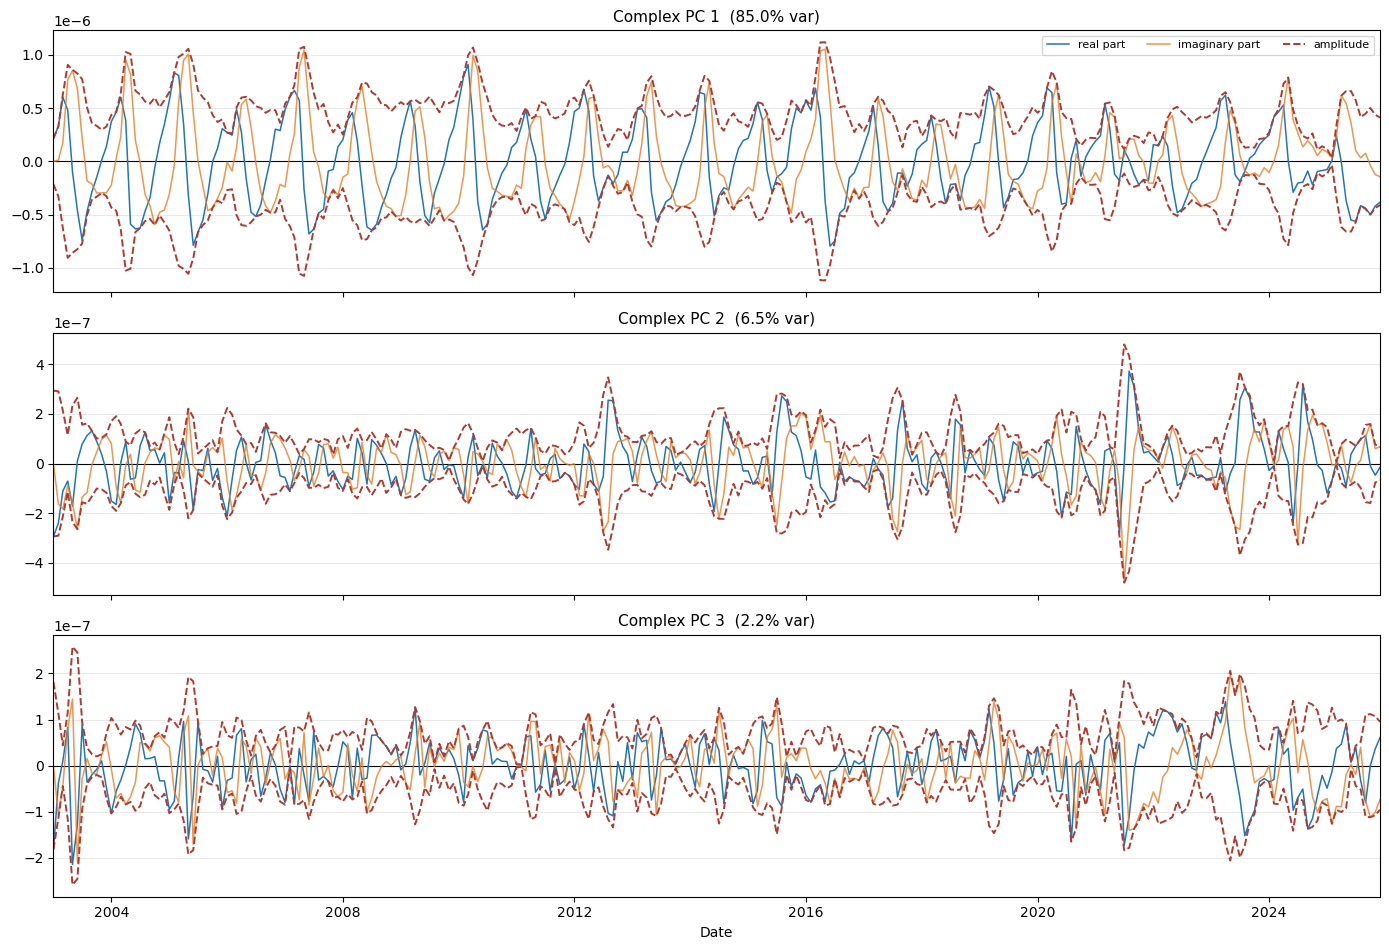

Saved -> ../Figures\ceof_pcs_2003_2025.png


In [37]:
# First 3 complex PCs: real & imaginary parts, plus the amplitude envelope.
fig_cp, axes_cp = plt.subplots(n_show, 1, figsize=(14, 3.2 * n_show), sharex=True)

for i in range(n_show):
    ax = axes_cp[i]
    pc_i = cpcs.sel(mode=i+1).values      # complex

    # Envelope taken from the PC itself, so it is on the same scale as the parts.
    env = np.abs(pc_i)

    ax.axhline(0, color="k", lw=0.8)
    ax.plot(months, pc_i.real, lw=1.1, color="#1f77b4", label="real part")
    ax.plot(months, pc_i.imag, lw=1.1, color="#e67e22", alpha=0.8, label="imaginary part")
    ax.plot(months, env,  lw=1.4, color="#b03a2e", ls="--", label="amplitude")
    ax.plot(months, -env, lw=1.4, color="#b03a2e", ls="--")

    ax.set_title(f"Complex PC {i+1}  ({cexpvar[i]:.1f}% var)", fontsize=11)
    ax.grid(axis="y", lw=0.4, alpha=0.5)
    if i == 0:
        ax.legend(fontsize=8, loc="upper right", ncol=3)

axes_cp[-1].set_xlabel("Date")
axes_cp[-1].set_xlim(months[0], months[-1])

fig_cp.tight_layout()
out_cp = os.path.join(OUT_DIR, "ceof_pcs_2003_2025.png")
fig_cp.savefig(out_cp, dpi=150, bbox_inches="tight")
plt.show()
print("Saved ->", out_cp)

**Do the complex-mode variances also add to 100%?** Same check as for the real EOF.

In [38]:
# Refit with every possible mode and sum the percentage variances.
n_time_c = detr_field.sizes["time"]

cmodel_all = HilbertEOF(n_modes=n_time_c, use_coslat=True, padding="exp",
                        decay_factor=0.2, solver="full")
cmodel_all.fit(detr_field, dim="time")
cexpvar_all = cmodel_all.explained_variance_ratio().values * 100

print(f"Modes returned              : {len(cexpvar_all)}")
print(f"Sum of percentage variances : {cexpvar_all.sum():.6f} %")
print(f"Equal to 100%? {np.isclose(cexpvar_all.sum(), 100.0)}")

Modes returned              : 276
Sum of percentage variances : 100.000000 %
Equal to 100%? True


## do the variances add to 100%?

In [ ]:
# Total possible modes, and whether all their variances add up to 100%.
n_time = detr_field.sizes["time"]
n_space = detr_field.sizes["lat"] * detr_field.sizes["lon"]


# Refit asking for every possible mode.
model_all = EOF(n_modes=n_time, use_coslat=True)
model_all.fit(detr_field, dim="time")
expvar_all = model_all.explained_variance_ratio().values * 100

total = expvar_all.sum()
print(f"\nModes returned : {len(expvar_all)}")
print(f"Sum of percentage variances : {total:.6f} %")
print(f"Equal to 100%? {np.isclose(total, 100.0)}")


Modes actually returned : 276
Sum of percentage variances : 100.000000 %
Equal to 100%? True


## EOF by hand (no xeofs), step by step



In [41]:
# Step 1: the data cube as numpy, shape (time, lat, lon)
X = detr_field.values

print("X shape:", X.shape)

X shape: (276, 36, 61)


area-weighting by square root of cos lat 

In [42]:
# Step 2: weight every pixel by sqrt(cos(lat))
w_lat = np.sqrt(np.cos(np.deg2rad(lats)))     # one weight per latitude row

Xw = X * w_lat[None, :, None]                 # broadcast over time and lon

print("Weight range:", w_lat.min().round(4), "-", w_lat.max().round(4))
print("Xw shape    :", Xw.shape)

Weight range: 0.8059 - 0.9839
Xw shape    : (276, 36, 61)


flatten data

In [43]:
# Step 3: (time, lat, lon) -> (time, pixel)
F = Xw.reshape(n_time, n_space)

print("F shape:", F.shape, " (rows = months, columns = pixels)")

F shape: (276, 2196)  (rows = months, columns = pixels)


remove time mean

In [44]:
# Step 4: subtract each pixel's own time mean (centre the columns)
F_mean = F.mean(axis=0)          # one number per pixel
Fc = F - F_mean

print("Largest remaining column mean:", np.abs(Fc.mean(axis=0)).max())

Largest remaining column mean: 1.3366759173864143e-24


Total variance

In [45]:
# Step 5: total variance = sum over pixels of each pixel's variance
total_variance = (Fc**2).sum() / (n_time)

print(f"Total variance of the weighted, centred data: {total_variance:.6e}")

Total variance of the weighted, centred data: 1.618534e-13


## SVD

$$F_c = U \, \Sigma \, V^{T}$$

* $V$ columns = the **EOFs** (spatial patterns),
* $U\Sigma$ columns = the **PCs** (how strongly each pattern shows up each month),
* $\Sigma$ = singular values, which give the variance of each mode.



In [30]:
# Step 6: SVD of the centred, weighted matrix
U, S, Vt = np.linalg.svd(Fc, full_matrices=False)

print("U  shape:", U.shape)
print("S  shape:", S.shape)
print("Vt shape:", Vt.shape)

U  shape: (276, 276)
S  shape: (276,)
Vt shape: (276, 2196)


Number of modes

In [46]:
# Step 7: count the modes
print("Singular values returned by SVD :", len(S))


n_keep = min(n_time , n_space)
S = S[:n_keep]
U = U[:, :n_keep]
Vt = Vt[:n_keep]

Singular values returned by SVD : 276


Variance of each mode

In [48]:
# Step 8: variance carried by each mode
mode_variance = S**2 / (n_time)

print("First 5 mode variances:", np.array2string(mode_variance[:5], precision=3))

First 5 mode variances: [1.332e-13 1.145e-14 6.026e-15 1.969e-15 1.446e-15]


Percentage variance and 100% check

In [50]:
# Step 9: percentage of variance per mode
pct_var = 100 * mode_variance / total_variance

for i in range(276):
    print(f"Mode {i+1:2d}: {pct_var[i]:.1f}% of variance")

print(f"\nTotal possible modes        : {n_keep}")
print(f"Sum of percentage variances : {pct_var.sum():.6f} %")
print(f"Equal to 100%? {np.isclose(pct_var.sum(), 100.0)}")

Mode  1: 82.3% of variance
Mode  2: 7.1% of variance
Mode  3: 3.7% of variance
Mode  4: 1.2% of variance
Mode  5: 0.9% of variance
Mode  6: 0.6% of variance
Mode  7: 0.5% of variance
Mode  8: 0.4% of variance
Mode  9: 0.3% of variance
Mode 10: 0.3% of variance
Mode 11: 0.2% of variance
Mode 12: 0.2% of variance
Mode 13: 0.1% of variance
Mode 14: 0.1% of variance
Mode 15: 0.1% of variance
Mode 16: 0.1% of variance
Mode 17: 0.1% of variance
Mode 18: 0.1% of variance
Mode 19: 0.1% of variance
Mode 20: 0.1% of variance
Mode 21: 0.1% of variance
Mode 22: 0.1% of variance
Mode 23: 0.1% of variance
Mode 24: 0.0% of variance
Mode 25: 0.0% of variance
Mode 26: 0.0% of variance
Mode 27: 0.0% of variance
Mode 28: 0.0% of variance
Mode 29: 0.0% of variance
Mode 30: 0.0% of variance
Mode 31: 0.0% of variance
Mode 32: 0.0% of variance
Mode 33: 0.0% of variance
Mode 34: 0.0% of variance
Mode 35: 0.0% of variance
Mode 36: 0.0% of variance
Mode 37: 0.0% of variance
Mode 38: 0.0% of variance
Mode 39: 0.

**pull out the spatial patterns (EOFs) and fold them back into maps.**
The $\sqrt{\cos(\text{lat})}$ weight is divided out again so the patterns are in the
units of the original field.

In [51]:
# Step 10: EOF maps  (mode, lat, lon)
eof_maps = Vt.reshape(n_keep, n_lat, n_lon)     # rows of Vt are the patterns

# Undo the area weighting.
eof_maps = eof_maps / w_lat[None, :, None]

print("eof_maps shape:", eof_maps.shape)

eof_maps shape: (276, 36, 61)


**the principal components (time series).**

In [52]:
# Step 11: PCs  (time, mode) = U * S
pc_series = U * S[None, :]

print("pc_series shape:", pc_series.shape)

pc_series shape: (276, 276)


**variance per mode and the running total.**

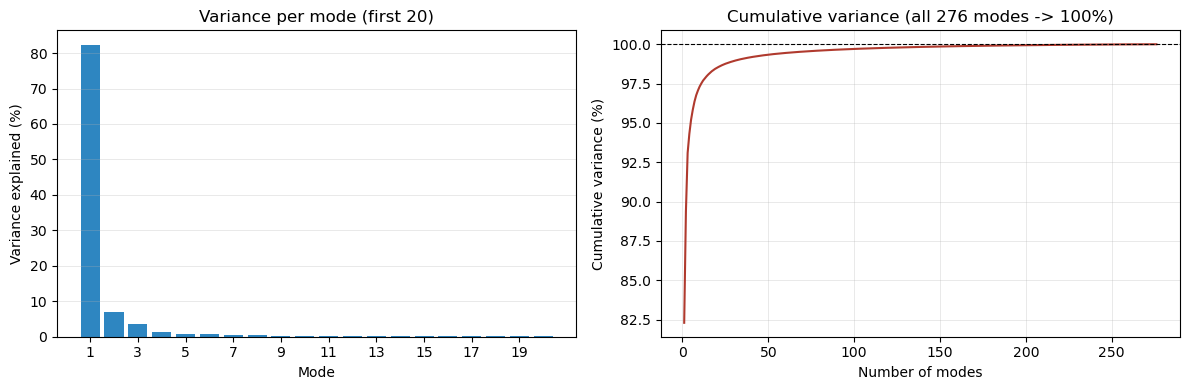

Saved -> ../Figures\eof_manual_scree_2003_2025.png


In [53]:
# Step 13: scree plot (first 20 modes) + cumulative curve (all modes)
fig_sc, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(12, 4))

ax_a.bar(np.arange(1, 21), pct_var[:20], color="#2e86c1")
ax_a.set_xlabel("Mode")
ax_a.set_ylabel("Variance explained (%)")
ax_a.set_title("Variance per mode (first 20)")
ax_a.set_xticks(np.arange(1, 21, 2))
ax_a.grid(axis="y", lw=0.4, alpha=0.5)

ax_b.plot(np.arange(1, n_keep + 1), np.cumsum(pct_var), lw=1.5, color="#b03a2e")
ax_b.axhline(100, color="k", lw=0.8, ls="--")
ax_b.set_xlabel("Number of modes")
ax_b.set_ylabel("Cumulative variance (%)")
ax_b.set_title(f"Cumulative variance (all {n_keep} modes -> 100%)")
ax_b.grid(lw=0.4, alpha=0.5)

fig_sc.tight_layout()
out_sc = os.path.join(OUT_DIR, "eof_manual_scree_2003_2025.png")
fig_sc.savefig(out_sc, dpi=150, bbox_inches="tight")
plt.show()
print("Saved ->", out_sc)

**first three modes: map on the left, PC on the right.**

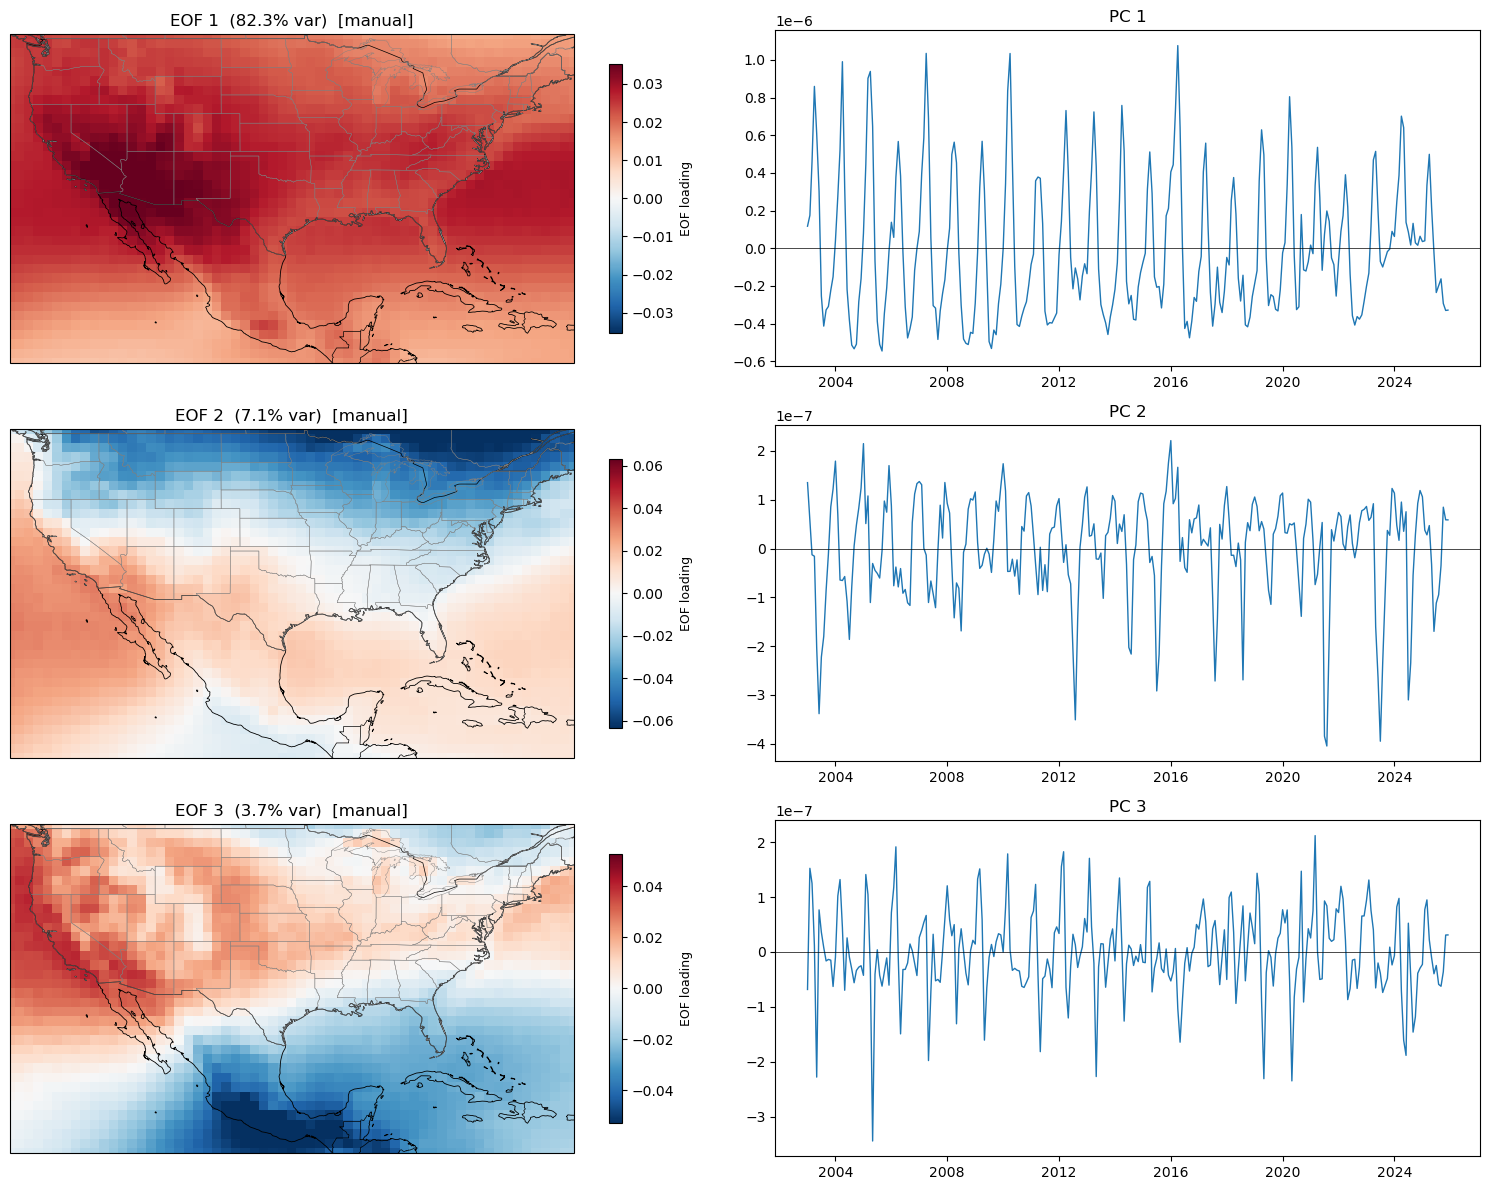

Saved -> ../Figures\eof_manual_modes_2003_2025.png


In [54]:
# Step 14: first 3 EOF maps and their PCs
n_show = 3
fig_m = plt.figure(figsize=(15, 4 * n_show))

for i in range(n_show):
    # Left: spatial pattern.
    ax_map = fig_m.add_subplot(n_show, 2, 2*i + 1, projection=ccrs.PlateCarree())
    ax_map.set_extent(ext, crs=ccrs.PlateCarree())
    ax_map.coastlines(linewidth=0.6)
    ax_map.add_feature(cfeature.BORDERS, lw=0.5)
    ax_map.add_feature(cfeature.STATES, lw=0.3, edgecolor="gray")

    vmax = np.nanpercentile(np.abs(eof_maps[i]), 98)
    pcm = ax_map.pcolormesh(lons, lats, eof_maps[i], transform=ccrs.PlateCarree(),
                            cmap="RdBu_r", vmin=-vmax, vmax=vmax, shading="nearest")
    cb = fig_m.colorbar(pcm, ax=ax_map, shrink=0.8)
    cb.set_label("EOF loading", fontsize=9)
    ax_map.set_title(f"EOF {i+1}  ({pct_var[i]:.1f}% var)  [manual]")

    # Right: matching time series.
    ax_pc = fig_m.add_subplot(n_show, 2, 2*i + 2)
    ax_pc.plot(months, pc_series[:, i], lw=1)
    ax_pc.axhline(0, color="k", lw=0.5)
    ax_pc.set_title(f"PC {i+1}")

fig_m.tight_layout()
out_m = os.path.join(OUT_DIR, "eof_manual_modes_2003_2025.png")
fig_m.savefig(out_m, dpi=150, bbox_inches="tight")
plt.show()
print("Saved ->", out_m)

## Harmonic analysis : 12 months, 6 months and 4 months harmonics

At every spatial grid point, the time series of the data is mathematically modeled as a superposition of fundamental cyclical waves—specifically, annual, semi-annual, and terannual cycles. Each cycle is initially constructed from a pair of sine and cosine functions, $a\cos(\omega t) + b\sin(\omega t)$. A least-squares regression is applied at each individual grid point to calculate the specific coefficients ($a$ and $b$) that best fit the model to the observed data. Once these coefficients are determined, the components are arranged into a standard sine convention, $A\sin(\omega t + \phi)$, to extract intuitive physical wave properties. The amplitude ($A$), representing the maximum strength of the cycle, is derived using the Pythagorean theorem $\sqrt{a^2 + b^2}$, and the phase ($\phi$), representing the timing of the cycle's peak, is found via the inverse tangent $\arctan(a/b)$. Finally, to allow for direct temporal comparison across different wave frequencies, the resulting phase angles are proportionally scaled to a unified 12-month calendar, ensuring that a given angular shift universally corresponds to the exact same physical time step across all cycles.

In [ ]:
# Setup and design matrix for harmonic regression
import numpy as np

# three periods
periods = [12, 6, 4]                                   
t = np.arange(len(months))   
print(f"Time vector t: {t} with shape {t.shape}  (0 to {len(months)-1})")                         

cols = []
for P in periods:
    w = 2 * np.pi / P
    cols += [np.cos(w * t), np.sin(w * t)]
    
# M becomes a matrix of shape (276 (number of months), 6)
M = np.column_stack(cols)
print(f"Design matrix M: {M} with shape {M.shape}  (time x 2*len(periods))")

Time vector t: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240 241 242

In [ ]:
# Flatten the spatial dimensions for the matrix operation
Yd = detr_field.values.reshape(len(months), -1)       

# Calculate the least-squares fit at every pixel at once
coef, *_ = np.linalg.lstsq(M, Yd, rcond=None)

In [ ]:
Yd

array([[ 7.30931982e-09,  7.04491035e-09,  6.97955394e-09, ...,
        -4.65221105e-09, -8.82748051e-10,  2.28060424e-09],
       [ 3.31798649e-09,  3.65101573e-09,  3.22342518e-09, ...,
        -1.34349362e-09,  5.85080344e-10,  2.97533047e-09],
       [ 5.84395008e-09,  5.26839428e-09,  5.45607035e-09, ...,
         4.24518492e-09,  6.58028099e-09,  1.08003389e-08],
       ...,
       [-5.95542158e-09, -5.78298673e-09, -5.08651770e-09, ...,
        -9.45642137e-09, -9.94943313e-09, -9.85427291e-09],
       [-4.93899182e-09, -5.14408947e-09, -6.12252544e-09, ...,
        -1.01823930e-08, -9.76024770e-09, -9.82597182e-09],
       [-4.92162778e-09, -5.12730791e-09, -6.10685176e-09, ...,
        -1.01538677e-08, -9.73007463e-09, -9.79321562e-09]],
      shape=(276, 2196))

In [ ]:
coef

array([[ 2.94280263e-09,  2.78995554e-09,  2.60119032e-09, ...,
        -5.49451720e-09, -4.41663000e-09, -3.17746178e-09],
       [ 3.85903465e-09,  3.78140038e-09,  3.69720877e-09, ...,
         6.29273260e-09,  6.33636059e-09,  6.33825243e-09],
       [-1.14323729e-09, -1.18119191e-09, -1.15644067e-09, ...,
        -8.36519303e-10, -5.27558626e-10, -1.89143301e-10],
       [-4.24901789e-10, -4.01750021e-10, -3.85263038e-10, ...,
         1.19583541e-09,  1.51828333e-09,  1.82646749e-09],
       [ 1.34322357e-09,  1.37164752e-09,  1.32597256e-09, ...,
        -7.59143483e-10, -8.72423280e-10, -9.07167095e-10],
       [-7.29010074e-10, -7.14681425e-10, -6.39828364e-10, ...,
        -2.21545908e-09, -2.07374969e-09, -2.03478234e-09]],
      shape=(6, 2196))

In [ ]:
amp, pha= {}, {}


for k, P in enumerate(periods):
    # Extract specific weights and fold back into the 2D map
    a_k = coef[2*k].reshape(n_lat, n_lon)
    b_k = coef[2*k + 1].reshape(n_lat, n_lon)
    
    # Amplitude
    amp[P] = np.sqrt(a_k**2 + b_k**2)
    
    # Phase calculation
    pha_rad = np.arctan2(a_k, b_k)

    # convert pha_rad (-pi to pi) to 0 to 2pi range 
    pha_rad = np.where(pha_rad < 0, pha_rad + 2 * np.pi, pha_rad)


    pha_deg = pha_rad * (180 / np.pi)       # rad to deg conversion
    
    
    pha[P] = pha_deg 

    

    # Print out minimum and maximum phase values for each period
    print(f"{P}: amp {np.nanmin(amp[P]):.2e} - {np.nanmax(amp[P]):.2e} kg/kg, "
          f"pha {np.nanmin(pha[P]):.2f} - {np.nanmax(pha[P]):.2f} degrees")
    

12: amp 3.53e-09 - 1.78e-08 kg/kg, pha 0.02 - 359.84 degrees
6: amp 1.06e-09 - 7.56e-09 kg/kg, pha 225.48 - 354.09 degrees
4: amp 9.36e-10 - 5.53e-09 kg/kg, pha 94.31 - 215.27 degrees


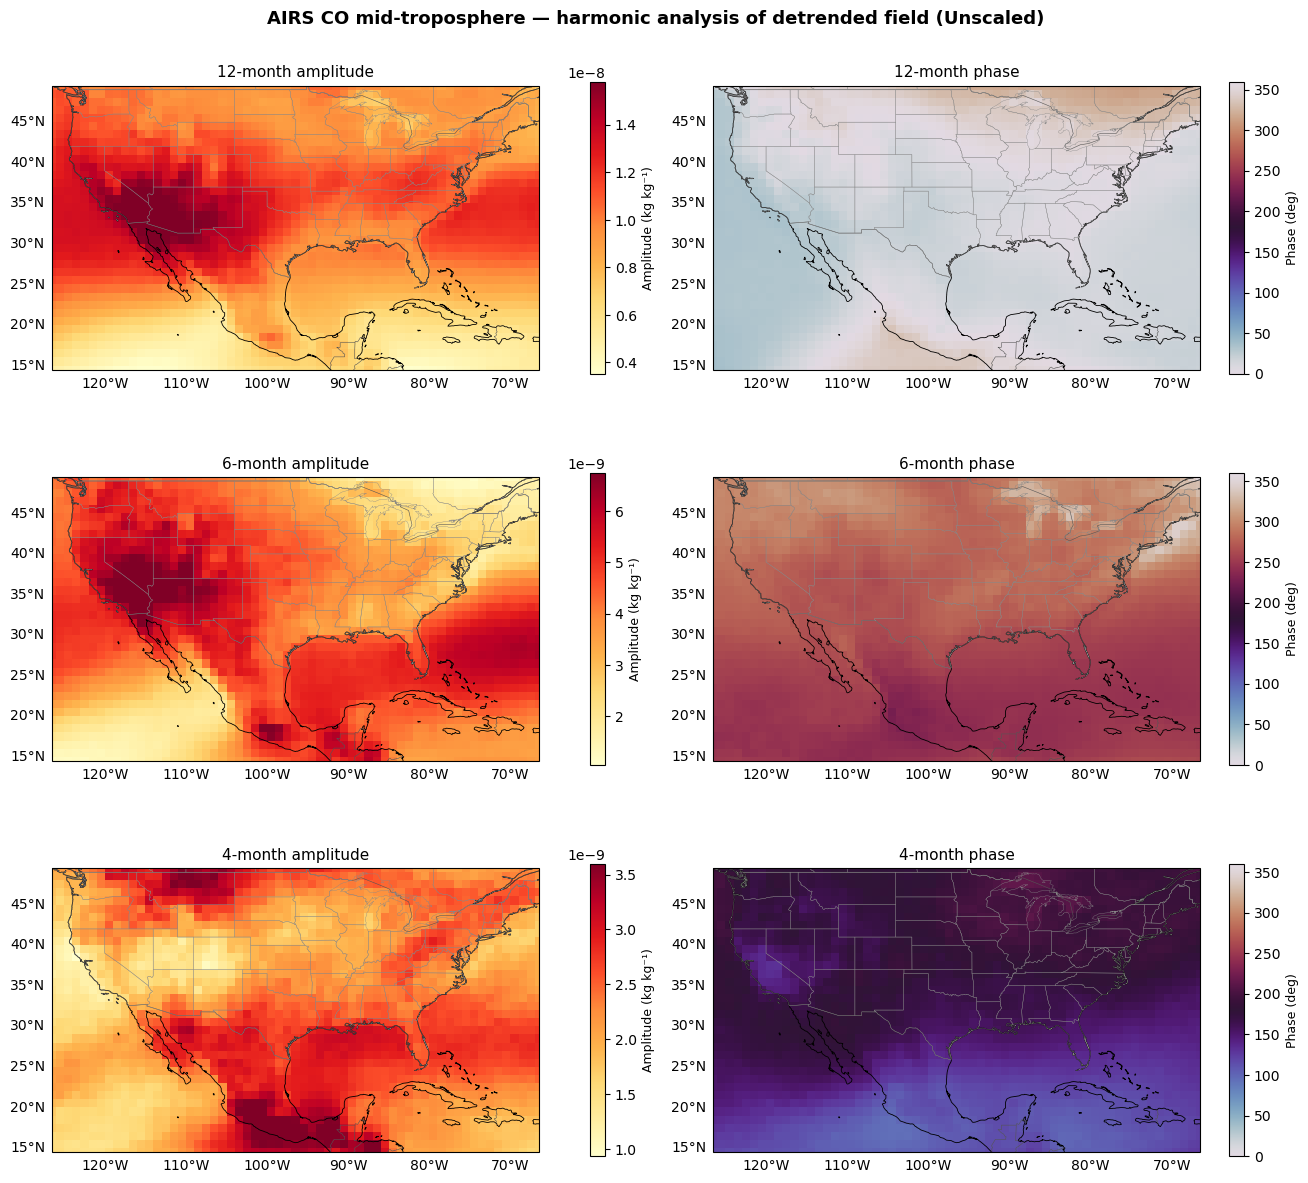

Saved -> ../Figures\harmonics_amp_phase_unscaled_2003_2025.png


In [ ]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import os

# 1. Update the theoretical maximum for the phase plots to a uniform 360 degrees
pha_max_uniform = 360

ext = [float(lons.min()), float(lons.max()), float(lats.min()), float(lats.max())]

fig_h, axes_h = plt.subplots(
    len(periods), 2, figsize=(13, 4 * len(periods)),
    subplot_kw={"projection": ccrs.PlateCarree()}, constrained_layout=True,
)

def harm_map(ax, data, cmap, label, title, vmin=None, vmax=None):
    ax.set_extent(ext, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor="k")
    ax.add_feature(cfeature.BORDERS,   linewidth=0.4, edgecolor="#555")
    ax.add_feature(cfeature.STATES,    linewidth=0.25, edgecolor="#888")
    pcm = ax.pcolormesh(lons, lats, data, transform=ccrs.PlateCarree(),
                        cmap=cmap, vmin=vmin, vmax=vmax, shading="nearest")
    gl = ax.gridlines(draw_labels=True, linewidth=0, color="none")
    gl.top_labels = gl.right_labels = False
    cb = fig_h.colorbar(pcm, ax=ax, orientation="vertical", fraction=0.03, pad=0.06)
    cb.set_label(label, fontsize=9)
    ax.set_title(title, fontsize=11, pad=6)

for r, P in enumerate(periods):
    # Amplitude plot
    harm_map(axes_h[r, 0], amp[P], "YlOrRd", "Amplitude (kg kg⁻¹)",
             f"{P}-month amplitude", vmax=np.nanpercentile(amp[P], 98))
    
    # Phase plot: Now using the uniform 360-degree max to show full cyclic range
    harm_map(axes_h[r, 1], pha[P], "twilight", "Phase (deg)",
             f"{P}-month phase", vmin=0, vmax=pha_max_uniform)

fig_h.suptitle("AIRS CO mid-troposphere — harmonic analysis of detrended field (Unscaled)",
               fontsize=13, fontweight="bold")
out_h = os.path.join(OUT_DIR, "harmonics_amp_phase_unscaled_2003_2025.png")
fig_h.savefig(out_h, dpi=150, bbox_inches="tight")
plt.show()
print("Saved ->", out_h)

In [ ]:
# Variance of the detrended data captured by each harmonic.
# Harmonics are orthogonal over the 23-yr record, so var = amp^2/2 and they add.
var_data = np.nansum(detr_field.var("time").values)        # domain-total variance

print("Variance explained (domain total):")
cum = 0.0
for P in periods:
    frac = 100 * np.nansum(amp[P]**2 / 2) / var_data
    cum += frac
    print(f"  {P:2d}-month: {frac:5.1f}%")
print(f"  total (12+6+4): {cum:5.1f}%")
print(f"  residual      : {100 - cum:5.1f}%")

Variance explained (domain total):
  12-month:  57.5%
   6-month:  10.6%
   4-month:   3.2%
  total (12+6+4):  71.3%
  residual      :  28.7%


## Sanity check - data reconstruction from the output of harmonic analysis

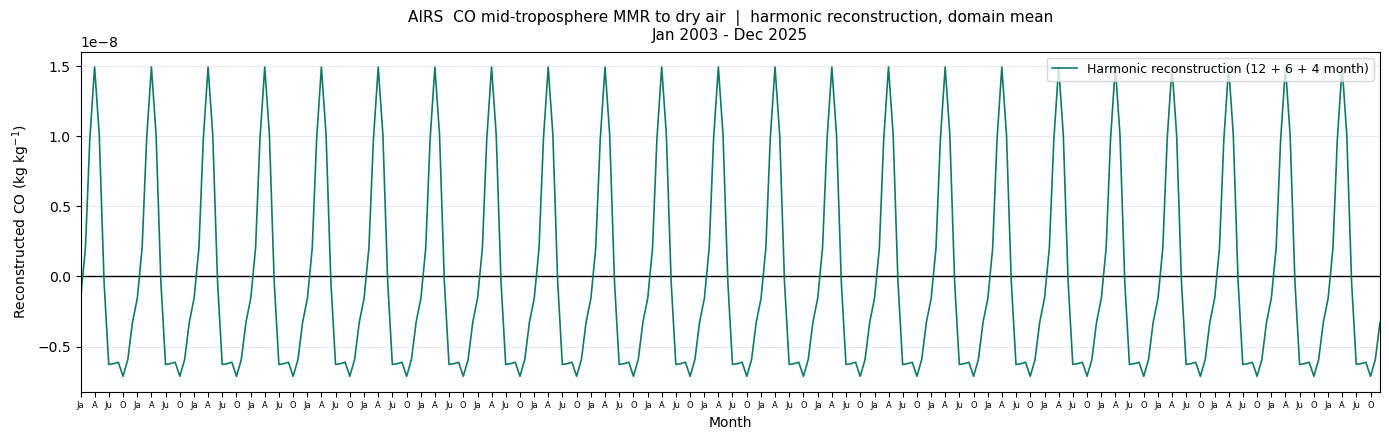

Saved -> ../Figures\timeseries_co_reconstructed_2003_2025.png


In [ ]:
# Reconstruct the seasonal field from the harmonic fit, plot its domain mean.
from matplotlib.ticker import FuncFormatter

reconstructed = xr.DataArray(
    (M @ coef).reshape(len(months), n_lat, n_lon),
    dims=("time", "lat", "lon"), coords=detr_field.coords,
)
recon_ts = reconstructed.mean(("lat", "lon")).values

fig_r, ax_r = plt.subplots(figsize=(14, 4.5))
ax_r.axhline(0, color="k", lw=1, zorder=2)
ax_r.plot(ts_dates, recon_ts, lw=1.2, color="#117a65",
          label="Harmonic reconstruction (12 + 6 + 4 month)")
ax_r.legend(fontsize=9, loc="upper right")

ax_r.set_title(
    f"AIRS  CO mid-troposphere MMR to dry air  |  harmonic reconstruction, domain mean\n"
    f"{ts_dates[0].strftime('%b %Y')} - {ts_dates[-1].strftime('%b %Y')}",
    fontsize=11, pad=8,
)
ax_r.set_ylabel("Reconstructed CO (kg kg$^{-1}$)", fontsize=10)
ax_r.set_xlabel("Month", fontsize=10)

# Ticks at Jan/Apr/Jul/Oct, labelled by letter.
letters = {1: "Ja", 4: "A", 7: "Ju", 10: "O"}
ax_r.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax_r.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: letters.get(mdates.num2date(x).month, "")))
ax_r.tick_params(axis="x", labelsize=6)
ax_r.grid(axis="y", lw=0.4, alpha=0.5)
ax_r.set_xlim(ts_dates[0], ts_dates[-1])

fig_r.tight_layout()
out_r = os.path.join(OUT_DIR, "timeseries_co_reconstructed_2003_2025.png")
fig_r.savefig(out_r, dpi=150, bbox_inches="tight")
plt.show()
print("Saved ->", out_r)

In [ ]:
# Month of max / min of the reconstructed seasonal cycle (domain mean).
recon_by_month = pd.Series(recon_ts, index=months).groupby(months.month).mean()
mx, mn = recon_by_month.idxmax(), recon_by_month.idxmin()
mname = lambda m: pd.Timestamp(2000, m, 1).strftime("%B")

print(f"Max: {mname(mx)}  ({recon_by_month[mx]:.4e} kg/kg)")
print(f"Min: {mname(mn)}  ({recon_by_month[mn]:.4e} kg/kg)")
print(f"Peak-to-peak: {recon_by_month[mx] - recon_by_month[mn]:.4e} kg/kg")

Max: April  (1.4943e-08 kg/kg)
Min: October  (-7.1151e-09 kg/kg)
Peak-to-peak: 2.2058e-08 kg/kg
